Implement no sklearn



## 1. Dataset

In [ ]:
import numpy as np

In [ ]:
np.random.seed(42)
X = np.random.rand(100 , 3)

true_w_ans = np.array([[2],[-1],[3]])
y = X @ true_w_ans + 5 + 0.5* np.random.randn(100 , 1)

## 2.Train - Test split

In [ ]:
ratio_train = 0.75
def train_test_split(X, y, train_ratio):
  indices = np.random.permutation(X.shape[0])
  train_size = int(X.shape[0] * train_ratio)

  X_train = X[indices[:train_size]]
  y_train = y[indices[:train_size]]
  X_test = X[indices[train_size:]]
  y_test = y[indices[train_size:]]

  return X_train, y_train, X_test, y_test

## 3.Predict function

In [ ]:
def predict(X_train , w , b):
  return X_train @ w + b

## 4. Loss function

In [ ]:
def loss_function(y_train , y_predict) :
  j = (1/2)*np.mean((y_predict - y_train)**2)
  return j

## 5.Gradient Descent

In [ ]:
from re import T
def gradient_descent(X_train, y_train ,y_predict ,w , b , learning_rate) :
  m = len(y_train)
  error = y_predict - y_train
  grad_w = (1/(2*m))*(X_train.T @ error)
  grad_b = np.mean(error)

  w = w - grad_w * learning_rate
  b = b - grad_b * learning_rate

  return w , b



## 6.Training

In [ ]:
w = np.random.rand(3,1)
b = np.random.rand(1)
learning_rate = 0.05
epochs = 1000

X_train , y_train , X_test , y_test = train_test_split(X , y , ratio_train)
loss_history = []

for epoch in range(epochs):
  y_predict = predict(X_train , w , b)
  loss = loss_function(y_train , y_predict)
  loss_history.append(loss)
  w , b = gradient_descent(X_train , y_train , y_predict , w , b , learning_rate)
  if (epoch + 1) % 50 == 0:
    print(f"Epoch {epoch+1}/{epochs} - Loss: {loss}")

Epoch 50/1000 - Loss: 0.5550106227587542
Epoch 100/1000 - Loss: 0.4552886498414354
Epoch 150/1000 - Loss: 0.3867256801441711
Epoch 200/1000 - Loss: 0.33227275884337387
Epoch 250/1000 - Loss: 0.28900640846320574
Epoch 300/1000 - Loss: 0.25461696202607076
Epoch 350/1000 - Loss: 0.2272732426885816
Epoch 400/1000 - Loss: 0.2055232023912964
Epoch 450/1000 - Loss: 0.18821523120211195
Epoch 500/1000 - Loss: 0.17443582759745893
Epoch 550/1000 - Loss: 0.16346022381863654
Epoch 600/1000 - Loss: 0.15471327008759855
Epoch 650/1000 - Loss: 0.14773844314426823
Epoch 700/1000 - Loss: 0.14217328914998612
Epoch 750/1000 - Loss: 0.13772996291466816
Epoch 800/1000 - Loss: 0.13417980397671125
Epoch 850/1000 - Loss: 0.13134111058939696
Epoch 900/1000 - Loss: 0.12906944724900002
Epoch 950/1000 - Loss: 0.12724995961638041
Epoch 1000/1000 - Loss: 0.12579128011584928


In [ ]:
print(f"True w:\n{true_w_ans.flatten()}")
print(f"Estimated w:\n{w.flatten()}")
print(f"True b: 5, Estimated b: {b[0]:.4f}")


True w:
[ 2 -1  3]
Estimated w:
[ 1.96383708 -0.8210079   3.04003617]
True b: 5, Estimated b: 4.9679


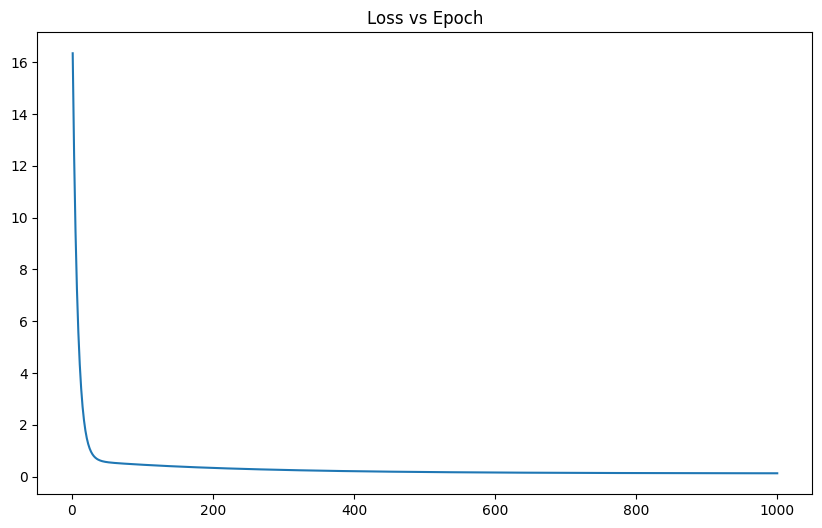

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(range(1 , epochs + 1),loss_history)
plt.xlabel = ('epoch')
plt.ylabel = ('loss')
plt.title('Loss vs Epoch')
plt.show()

## 7.Test

In [ ]:

y_test_pred = predict(X_test, w, b)
def evaluate_model(y_test, y_pred):
    m = len(y_test)
    mse = (1 / m) * np.sum((y_pred - y_test)**2)
    rmse = np.sqrt(mse)

    # R-squared
    # R2 = 1 - (Tổng bình phương phần dư / Tổng bình phương tổng thể)
    ss_res = np.sum((y_test - y_pred)**2)
    ss_tot = np.sum((y_test - np.mean(y_test))**2)
    r2 = 1 - (ss_res / ss_tot)
    return mse, rmse, r2

mse_test, rmse_test, r2_test = evaluate_model(y_test, y_test_pred)

print("\n" + "="*40)
print("KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST")
print("="*40)
print(f"MSE  (Mean Squared Error):      {mse_test:.4f}")
print(f"RMSE (Root Mean Squared Error): {rmse_test:.4f}")
print(f"R2 Score:                       {r2_test:.4f}")
print("-" * 40)


KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST
MSE  (Mean Squared Error):      0.2203
RMSE (Root Mean Squared Error): 0.4694
R2 Score:                       0.8331
----------------------------------------


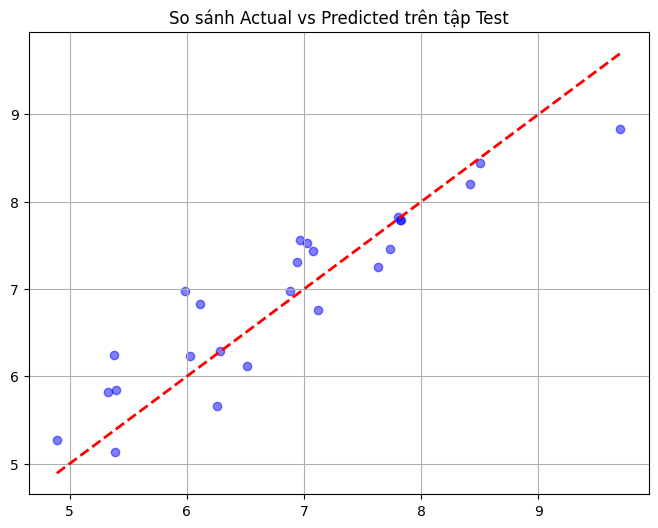

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_teưst.max()], 'r--', lw=2)
plt.xlabel = ('Actual y ')
plt.ylabel = ('Predicted y')
plt.title('So sánh Actual vs Predicted trên tập Test')
plt.grid(True)
plt.show()

sklearn

## 8. Linear Regression with Scikit-learn

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

sklearn_model = LinearRegression()
sklearn_model.fit(X_train, y_train)
sklearn_y_pred = sklearn_model.predict(X_test)

# Evaluate the model
sklearn_mse = mean_squared_error(y_test, sklearn_y_pred)
sklearn_rmse = np.sqrt(sklearn_mse)
sklearn_r2 = r2_score(y_test, sklearn_y_pred)

print("\n" + "="*40)
print("KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST (SKLEARN)")
print("="*40)
print(f"MSE  (Mean Squared Error):      {sklearn_mse:.4f}")
print(f"RMSE (Root Mean Squared Error): {sklearn_rmse:.4f}")
print(f"R2 Score:                       {sklearn_r2:.4f}")
print("-" * 40)

print(f"Estimated w (Sklearn):\n{sklearn_model.coef_.flatten()}")
print(f"Estimated b (Sklearn): {sklearn_model.intercept_[0]:.4f}")


KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST (SKLEARN)
MSE  (Mean Squared Error):      0.2052
RMSE (Root Mean Squared Error): 0.4530
R2 Score:                       0.8445
----------------------------------------
Estimated w (Sklearn):
[ 2.1530039  -1.0471847   3.27910803]
Estimated b (Sklearn): 4.8721


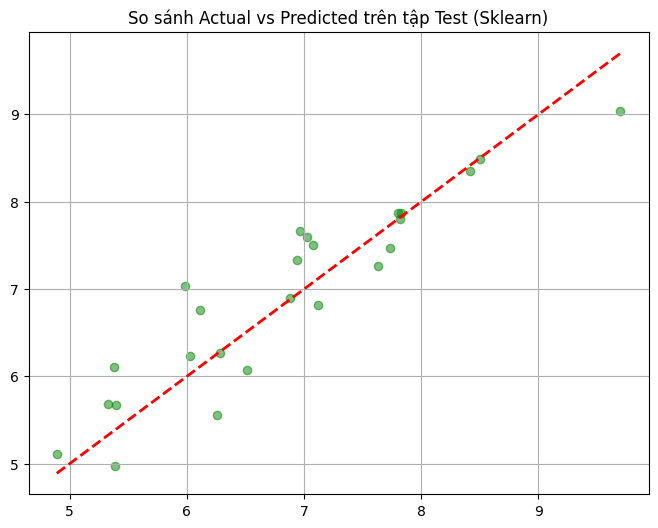

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, sklearn_y_pred, alpha=0.5, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel = ('Actual y ')
plt.ylabel = ('Predicted y (Sklearn)')
plt.title('So sánh Actual vs Predicted trên tập Test (Sklearn)')
plt.grid(True)
plt.show()